In [1]:
#This script uses the bead positions to calculate the length and angle between two catenated DNAs.
#It assumes the length of the DNAs is the same. 
#This approximation behaves well at <15N forces, in the assay conditions used, but should be verified in different conditions.

#Written by Erin E. Cutts, Univeristy fo Sheffield
#Corresponding address e.cutts@sheffield.ac.uk
#please cite: Cutts, E. E., Saravanan, S., Fisher, G. L. M., Rueda, D. S. & Aragon, L. bioRxiv (2023) https://doi.org/10.1101/2023.11.20.567865.

import lumicks.pylake as lk
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
import math

# Function to calculate DNA crossing point, X, assuming length of DNA1=DNA2
def objective_function(X, *args):
    B1, B2, B3, B4 = args
    distance_sum1 = np.linalg.norm(B1 - X) + np.linalg.norm(B2 - X)
    distance_sum2 = np.linalg.norm(B3 - X) + np.linalg.norm(B4 - X)
    return np.abs(distance_sum1 - distance_sum2)
def minimize_difference(B1, B2, B3, B4):
    initial_guess = np.mean([B1, B2, B3, B4], axis=0)  # Starting point for optimization
    result = minimize(objective_function, initial_guess, args=(B1, B2, B3, B4), method='SLSQP')
    return result.x


(25.0, 50.0)

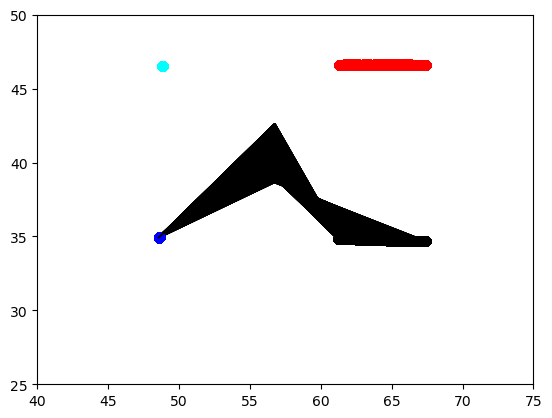

In [2]:
#load in your file
#This data is collected by zeroing, then fixing the distance between one set of beads, and varying the other.
#then swapping, after rezeroing. Care need to be taken to zero where the force should be zero.
file = lk.File("20230519-141426 FD Curve DNA22_knotted_FD.h5")

beadsize=4.3 #the bead size you use, in um. The bead tracking finds to center of the beads, hence the bead size needs to be subtracted

DNAdist=[] #Stores your corrected DNA distance, for each time point
X=[] #stores your DNA crossing point, at each time point

#First, pull out the x and y positions of each of your beads.
b1x=file['Bead position']['Bead 1 X']
b1y=file['Bead position']['Bead 1 Y']

b2x=file['Bead position']['Bead 2 X']
b2y=file['Bead position']['Bead 2 Y']

b3x=file['Bead position']['Bead 3 X']
b3y=file['Bead position']['Bead 3 Y']

b4x=file['Bead position']['Bead 4 X']
b4y=file['Bead position']['Bead 4 Y']

for i in range(0, len(b1x.data)):
    B1=[b1x.data[i],b1y.data[i]]
    B2=[b2x.data[i],b2y.data[i]]
    B3=[b3x.data[i],b3y.data[i]]
    B4=[b4x.data[i],b4y.data[i]]
    central_point = minimize_difference(B1, B2, B3, B4)
    DNAdist.append(math.dist(central_point, B1)+math.dist(central_point, B2)-beadsize) 
    X.append(central_point)
    D1C=(b1x.data[i], central_point[0], b2x.data[i])
    D2C=(b1y.data[i], central_point[1], b2y.data[i])
    #I recommend you plot the bead positions. 
    #Bead number and trap number are not necessarily the same, so plotting the colour of each helps you orient.
    plt.plot(b1x.data,b1y.data,'o',color='blue')
    plt.plot(b2x.data,b2y.data,'o',color='black')
    plt.plot(b3x.data,b3y.data,'o',color='cyan')
    plt.plot(b4x.data,b4y.data,'o',color='red')
    #How DNA1 changes
    plt.plot(D1C,D2C,color='Black')



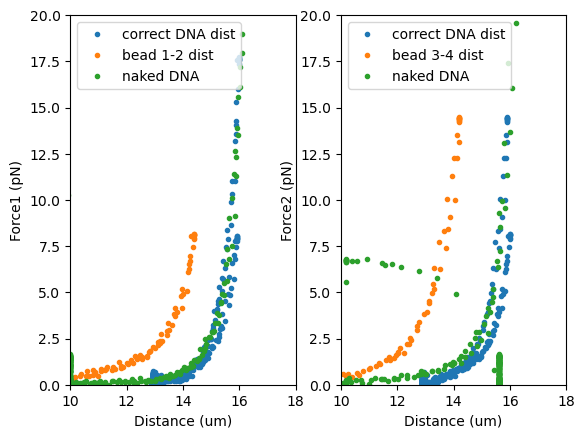

In [4]:
#Having verified bead and DNA movement, we can now plot some FD curves.

#We have to pull out the forces being measured.
#Bead tracking is done at low frequency, LF, so we use these forces and get the same number of data points.
#Forces are measured in Trap1 and Trap4, which when your using the C-trap is the two on the left hand side.
#In our case, this is bead 1 and 3
#Be careful to ensure you zero the force when the force is indeed zero, or this will result in offsets.
F1x=file['Force LF']['Force 1x']
F1y=file['Force LF']['Force 1y']
F2x=file['Force LF']['Force 2x']
F2y=file['Force LF']['Force 2y']

#This distance is the shortest distance between sets of beads.
#This is set on the Ctrap as four beads, with parrallel lines connecting, is =, no the x or +
dist1=file['Distance']['Distance 1']
dist2=file['Distance']['Distance 2']

#We need to convert the x and y force into net force by using pythagoras
Force1=[]
for d in range(0, len(F1x.data)):
    Force1.append(((F1x.data[d])*(F1x.data[d])+((F1y.data[d])*(F1y.data[d])))**(0.5))
Force2=[]
for d in range(0, len(F2x.data)):
    Force2.append(((F2x.data[d])*(F2x.data[d])+((F2y.data[d])*(F2y.data[d])))**(0.5))
    
    
#To compare to non-catenated DNA, load in data prior to braiding the DNA.     
file2 = lk.File("20230519-141158 FD Curve DNA22_naked_FD.h5") 
F1x2=file2['Force LF']['Force 1x']
F1y2=file2['Force LF']['Force 1y']
F2x2=file2['Force LF']['Force 2x']
F2y2=file2['Force LF']['Force 2y']
distN1=file2['Distance']['Distance 1']
distN2=file2['Distance']['Distance 2']
ForceN1=[]
ForceN2=[]
for d in range(0, len(F1x2.data)):
    ForceN1.append(((F1x2.data[d])*(F1x2.data[d])+((F1y2.data[d])*(F1y2.data[d])))**(0.5))
    ForceN2.append(((F2x2.data[d])*(F2x2.data[d])+((F2y2.data[d])*(F2y2.data[d])))**(0.5))

#Plot FD curve for DNA1    
plt.subplot(1,2,1)
plt.plot(DNAdist,Force1,'.', label='correct DNA dist')
plt.plot(dist1.data, Force2,'.',label='bead 1-2 dist')
plt.plot(distN1.data, ForceN1,'.', label='naked DNA')
plt.ylim(0,20)
plt.xlim(10,18)
plt.legend(loc='upper left')
plt.xlabel('Distance (um)')
plt.ylabel('Force1 (pN)')

#Plot FD curve for DNA2
plt.subplot(1,2,2)
plt.plot(DNAdist,Force2, '.',label='correct DNA dist')
plt.plot(dist2.data, Force2, '.', label='bead 3-4 dist')
plt.plot(distN2.data, ForceN2,'.', label='naked DNA')
plt.ylim(0,20)
plt.xlim(10,18)
plt.legend(loc='upper left')
plt.xlabel('Distance (um)')
plt.ylabel('Force2 (pN)')
plt.savefig('DNA22co_force.pdf')

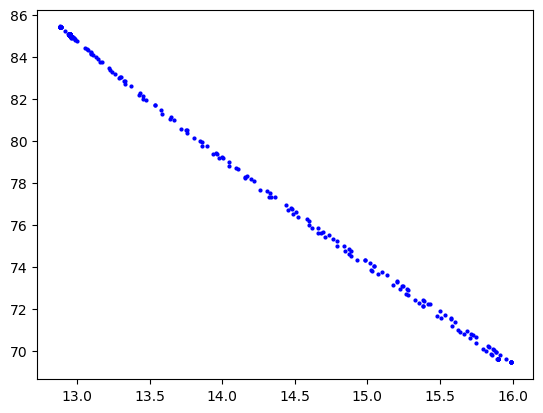

In [18]:
#now we can calculate angles
#Put this in a loop to plot for a list of files

crossing_angle=[]

for j in range(0, len(b1x)): #For this example, we are calculating the entire data set, to examine how this changes with distance.
    #For angle analysis in TOP2 work, I limited this to the intial data points, as geometry was fixed during the experiment
    B1=[b1x.data[j],b1y.data[j]]
    B2=[b2x.data[j],b2y.data[j]]
    B3=[b3x.data[j],b3y.data[j]]
    B4=[b4x.data[j],b4y.data[j]]
    
    central_point = minimize_difference(B1, B2, B3, B4)
    DNAdist.append(math.dist(central_point, B1)+math.dist(central_point, B2)-beadsize) 
    X.append(central_point)
    
    #Determine the vectors between the two left hand beads and the central point
    vector1 = B1 - central_point
    vector2 = B3 - central_point
    #Determine the crossing angle between them
    cos_angle = np.clip(np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2)), -1.0, 1.0)
    ang = np.degrees(np.arccos(cos_angle))
    crossing_angle.append(ang)
    
#plot how the crossing angle changes as the FD curve is collected    
for d in range(0, len(crossing_angle)):
    y3=crossing_angle[d]
    x3=DNAdist[d]
    plt.plot(x3,y3,'.', color='blue',label='DNA distance',markersize=4)

